# Modelos Avanzados.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, root_mean_squared_error

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

In [17]:
df = pd.read_csv("data/visitas_proc_1.csv", index_col="fecha", parse_dates= True)
df

,visitas,anio,mes,dia_semana,numero_semana
fecha,,,,,
2022-01-01,109,2022,1,Saturday,1
2022-01-02,137,2022,1,Sunday,1
2022-01-03,164,2022,1,Monday,2
2022-01-04,156,2022,1,Tuesday,2
2022-01-05,78,2022,1,Wednesday,2
...,...,...,...,...,...
2023-12-27,268,2023,12,Wednesday,53
2023-12-28,246,2023,12,Thursday,53
2023-12-29,264,2023,12,Friday,53


## Creamos nuestras variables y target.

In [18]:
df_modelo = df.copy()

df_modelo['mes'] = df_modelo.index.month
df_modelo['día_semana'] = df_modelo.index.dayofweek
df_modelo['es_fin_semana'] = (df_modelo['día_semana'] >= 5).astype(int)
df_modelo['visitas_lag_1'] = df_modelo['visitas'].shift(1)
df_modelo['visitas_lag_7'] = df_modelo['visitas'].shift(7)
df_modelo['promedio_móvil_7'] = df_modelo['visitas'].rolling(window=7).mean()

df_modelo['visitas_mañana'] = df_modelo['visitas'].shift(-1)


In [19]:
df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 730 entries, 2022-01-01 to 2023-12-31
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   visitas           730 non-null    int64  
 1   anio              730 non-null    int64  
 2   mes               730 non-null    int32  
 3   dia_semana        730 non-null    object 
 4   numero_semana     730 non-null    int64  
 5   día_semana        730 non-null    int32  
 6   es_fin_semana     730 non-null    int64  
 7   visitas_lag_1     729 non-null    float64
 8   visitas_lag_7     723 non-null    float64
 9   promedio_móvil_7  724 non-null    float64
 10  visitas_mañana    729 non-null    float64
dtypes: float64(4), int32(2), int64(4), object(1)
memory usage: 62.7+ KB


In [20]:
df_modelo

,visitas,anio,mes,dia_semana,numero_semana,día_semana,es_fin_semana,visitas_lag_1,visitas_lag_7,promedio_móvil_7,visitas_mañana
fecha,,,,,,,,,,,
2022-01-01,109,2022,1,Saturday,1,5,1,NaN,NaN,NaN,137.0
2022-01-02,137,2022,1,Sunday,1,6,1,109.0,NaN,NaN,164.0
2022-01-03,164,2022,1,Monday,2,0,0,137.0,NaN,NaN,156.0
2022-01-04,156,2022,1,Tuesday,2,1,0,164.0,NaN,NaN,78.0
2022-01-05,78,2022,1,Wednesday,2,2,0,156.0,NaN,NaN,53.0
...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,268,2023,12,Wednesday,53,2,0,317.0,255.0,283.428571,246.0
2023-12-28,246,2023,12,Thursday,53,3,0,268.0,236.0,284.857143,264.0
2023-12-29,264,2023,12,Friday,53,4,0,246.0,254.0,286.285714,286.0


### IMPORTANTE!! Definirle al modelo nuestra frecuencia.

Los modelos estadísticos clásicos como ARIMA y SARIMA no miran las fechas; miran los saltos entre filas. Dan por sentado que la distancia en el tiempo entre las filas.

In [21]:
df_modelo = df_modelo.asfreq('D')

## Separamos en X_train, y_train, X_test e y_test.

In [22]:
# 80% para entrenamiento, 20% para prueba
split_idx = int(len(df_modelo) * 0.8)

# Solo para evaluar.
X_train = df_modelo[['mes', 'día_semana', 'es_fin_semana', 'visitas_lag_1', 'visitas_lag_7', 'promedio_móvil_7']].iloc[:split_idx]
X_test  = df_modelo[['mes', 'día_semana', 'es_fin_semana', 'visitas_lag_1', 'visitas_lag_7', 'promedio_móvil_7']].iloc[split_idx:]


# El Target real: lo que queremos predecir (visitas_mañana)
y_train = df_modelo['visitas_mañana'].iloc[:split_idx]
y_test  = df_modelo['visitas_mañana'].iloc[split_idx:]

print("------ TRAIN ------")
print("Longitud de entrenamiento: ", len(y_train))
print(f"Rango de {y_train.index.min()} a {y_train.index.max()}")
print("Shape de train: ", y_train.shape)


print("------ TEST ------")
print("Longitud de TEST: ", len(y_test))
print(f"Rango de {y_test.index.min()} a {y_test.index.max()}")
print("Shape de test: ", y_test.shape)


------ TRAIN ------
Longitud de entrenamiento:  584
Rango de 2022-01-01 00:00:00 a 2023-08-07 00:00:00
Shape de train:  (584,)
------ TEST ------
Longitud de TEST:  146
Rango de 2023-08-08 00:00:00 a 2023-12-31 00:00:00
Shape de test:  (146,)


### Con el metodo .diff() generamos la diferencia restando al valor de la tarteg, el valor de otro dia. Este metodo conseguir la estacionaridad.

### En este caso utilizamos el valor de **7** para restarle el valor de el mismo dia de la semana anterior.

In [34]:
y_train_arima_prep = y_train.diff(7).dropna()
#y_train_arima_prep = y_train.dropna()
y_train_arima_prep

fecha
2022-01-08     3.0
2022-01-09     7.0
2022-01-10   -31.0
2022-01-11     5.0
2022-01-12    18.0
              ... 
2023-08-03     6.0
2023-08-04   -29.0
2023-08-05    52.0
2023-08-06    36.0
2023-08-07   -16.0
Freq: D, Name: visitas_mañana, Length: 577, dtype: float64

In [35]:
len(y_train_arima_prep)

577

In [36]:
y_test = y_test.dropna()
y_test

fecha
2023-08-08    207.0
2023-08-09    165.0
2023-08-10    167.0
2023-08-11    239.0
2023-08-12    244.0
              ...  
2023-12-26    268.0
2023-12-27    246.0
2023-12-28    264.0
2023-12-29    286.0
2023-12-30    322.0
Freq: D, Name: visitas_mañana, Length: 145, dtype: float64

### Parametros importantes para los modelos ARIMA Y SARIMAX.

| Parámetro | Posición | Tipo | Descripción y Propósito en el Aprendizaje | Ejemplo Práctico |
| :--- | :---: | :--- | :--- | :--- |
| **`p`** (AR) | 1ª | Entero | **Orden Autorregresivo regular.** Número de días consecutivos hacia atrás que el modelo consulta para entender el valor de hoy. | Si `p=1`, el modelo usa el valor de ayer para predecir hoy. |
| **`d`** (I) | 2ª | Entero | **Orden de Integración regular.** Cuántas diferenciaciones normales (restar hoy menos ayer) hace el modelo para eliminar tendencias. | Si `d=1`, el modelo resta $Y_t - Y_{t-1}$ internamente para aplanar la serie. |
| **`q`** (MA) | 3ª | Entero | **Orden de Media Móvil regular.** Cuántos errores de predicción pasados (ruido inmediato) usa para autocorregir el rumbo actual. | Si `q=1`, el modelo mira qué tanto se equivocó ayer para ajustar el tiro hoy. |

## ARIMA
Es un modelo estadístico clásico que predice el futuro basándose únicamente en la historia de la propia variable. Utiliza la inercia de los días pasados (AR) y los errores cometidos recientemente (MA) tras haber aplanado la serie (I). Está completamente ciego ante la estacionalidad.

In [42]:
# Configuración ARIMA básica: order=(p, d, q). d=0 porque ya la diferenciamos a mano[cite: 535, 537, 540, 544].
modelo_arima = ARIMA(y_train_arima_prep, order=(1, 0, 1)).fit()

# Predicción: Generamos tantos pasos hacia el futuro como filas tiene el conjunto de test
pred_arima_diff = modelo_arima.forecast(steps=len(y_test))

# Reconstrucción: Como ARIMA predijo en la serie diferenciada, le sumamos el valor real de 
# hace 7 días (el desfase estacional) para devolver las predicciones a la escala original de visitas.
pred_arima = pred_arima_diff.values + y_train.iloc[-len(y_test):].values

mae_arima = mean_absolute_error(y_test, pred_arima)
rmse_arima = root_mean_squared_error(y_test, pred_arima)

print("MAE ARIMA: ", mae_arima)
print("RMSE ARIMA: ", rmse_arima)

MAE ARIMA:  61.56895619355174
RMSE ARIMA:  76.7667165667681


## SARIMAX

Es la evolución definitiva de ARIMA. Mantiene toda la lógica anterior pero añade dos superpoderes: entiende y replica los patrones cíclicos del calendario (la S de Seasonal) y permite inyectar variables del mundo exterior (la X de Exogenous), como festivos o campañas de marketing.

In [43]:
len(y_test)

145

In [44]:
modelo_sarimax = SARIMAX(y_train, order=(1, 0, 1), seasonal_order=(1, 1, 1, 7)).fit(disp=False)

# Predicción directa sobre el horizonte del 20% de test
pred_sarimax = modelo_sarimax.forecast(steps=len(y_test))

mae_sarimax = mean_absolute_error(y_test, pred_sarimax)
rmse_sarimax = root_mean_squared_error(y_test, pred_sarimax)

print("MAE SARIMAX: ", mae_sarimax)
print("RMSE SARIMAX: ", rmse_sarimax)

MAE SARIMAX:  26.033565140254616
RMSE SARIMAX:  31.617744980283444


1. Cuándo usar ARIMA (Series simples, estables y sin ciclos)
Úsalo cuando tus datos cambian con el tiempo pero no tienen picos ni valles repetitivos en fechas fijas del calendario (sin estacionalidad).

    - Ejemplo 1 (Finanzas): Predecir el precio de cierre de la acción de Apple o el valor del Bitcoin. (Suben o bajan por tendencia, pero no hay un "efecto fin de semana" o "efecto Navidad" constante).

    - Ejemplo 2 (Procesos): Medir la presión de una caldera industrial minuto a minuto o el ritmo de desintegración de un componente químico.

2. Cuándo usar SARIMAX (El estándar para el mundo de los negocios)
Úsalo obligatoriamente cuando tus datos tengan patrones repetitivos de calendario (días de la semana, meses del año) y cuando sepas que el entorno exterior influye en el resultado.

    - Ejemplo 1 (Tu caso de Visitas Web / Retail): Predicción de tráfico o ventas diarias. Hay un ciclo clarísimo de 7 días (los fines de semana son radicalmente distintos a los lunes) y además el tráfico explota si haces una campaña de publicidad (variable exógena).

    - Ejemplo 2 (Energía): Predecir el consumo de luz por horas. Hay una estacionalidad diaria (se gasta más al mediodía que de madrugada), una estacionalidad semanal (fábricas cerradas los domingos) y depende de una variable exógena crítica: la temperatura del clima.

## Facebook Prophet

In [45]:
df_train_p = pd.DataFrame({'ds': y_train.index, 'y': y_train.values})
df_test_p = pd.DataFrame({'ds': y_test.index, 'y': y_test.values})

# Instanciamos activando las estacionalidades que detectamos en tus datos
modelo_prophet = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
modelo_prophet.fit(df_train_p)

# Predecimos pasando un dataframe que contenga únicamente las fechas del futuro (test)
forecast = modelo_prophet.predict(df_test_p[['ds']])
pred_prophet = forecast['yhat'].values

mae_prophet = mean_absolute_error(y_test, pred_prophet)
rmse_prophet = root_mean_squared_error(y_test, pred_prophet)

print("MAE PROPHET: ", mae_prophet)
print("RMSE PROPHET: ", rmse_prophet)

10:04:37 - cmdstanpy - INFO - Chain [1] start processing
10:04:38 - cmdstanpy - INFO - Chain [1] done processing


MAE PROPHET:  16.38839551572776
RMSE PROPHET:  20.73436832902227


## Evaluaciones.

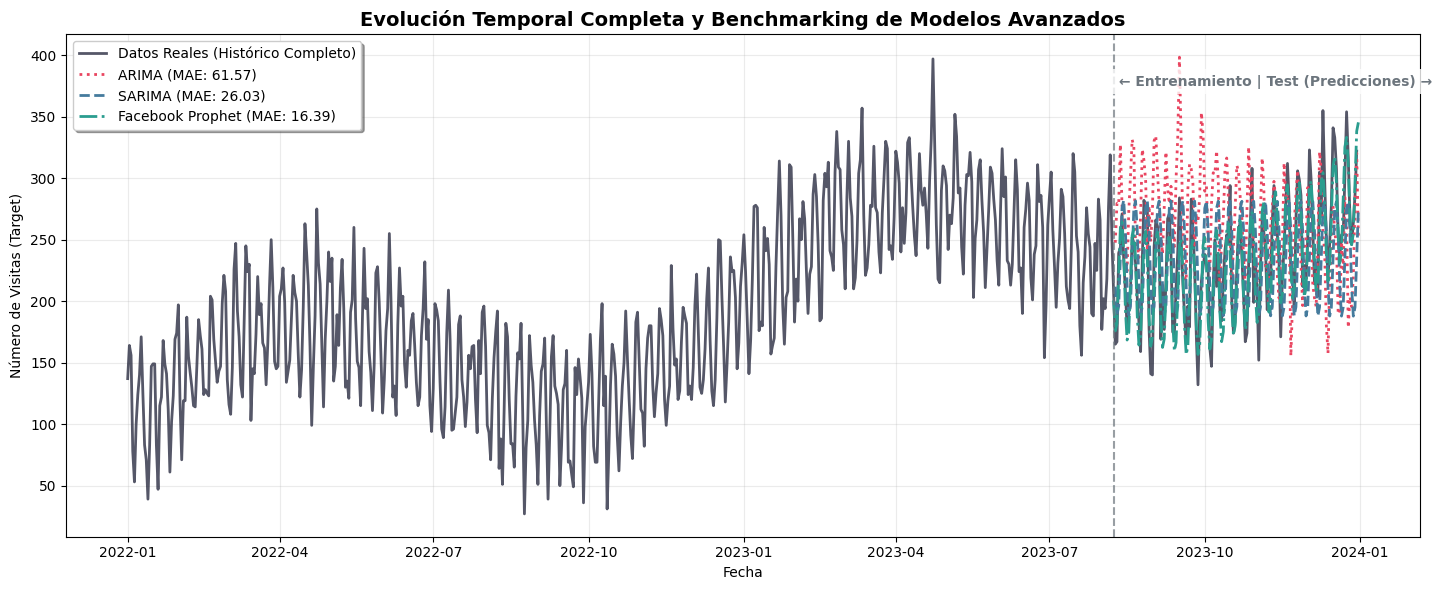

In [50]:
# 1. Crear la figura principal
plt.figure(figsize=(15, 6))

# 2. Pintar TODO el dataset histórico real (Train + Test continuo)
# Usamos una línea gris o oscura de fondo para representar la realidad histórica
plt.plot(df_modelo.index, df_modelo['visitas_mañana'], 
         label='Datos Reales (Histórico Completo)', color='#2B2D42', linewidth=2, alpha=0.8)

# 3. Crear series alineadas con el índice completo del dataset para los modelos
# Llenamos con NaN el tamaño de Train para que empiecen justo en la continuación (Test)
nan_padding = [np.nan] * len(X_train)

pred_arima_completo = nan_padding + list(pred_arima)
pred_sarima_completo = nan_padding + list(pred_sarimax)
pred_prophet_completo = nan_padding + list(pred_prophet)

# 4. Pintar las predicciones de los modelos a partir de la continuación de Test
#plt.plot(df_modelo.index, pred_arima_completo, 
#         label=f'ARIMA (MAE: {mae_arima:.2f})', linestyle=':', color='#E94560', linewidth=2)
plt.plot(df_modelo.index[-len(pred_arima_completo):], pred_arima_completo, 
         label=f'ARIMA (MAE: {mae_arima:.2f})', linestyle=':', color='#E94560', linewidth=2)


plt.plot(df_modelo.index[-len(pred_sarima_completo):], pred_sarima_completo, 
         label=f'SARIMA (MAE: {mae_sarimax:.2f})', linestyle='--', color='#457B9D', linewidth=2)

plt.plot(df_modelo.index[-len(pred_prophet_completo):], pred_prophet_completo, 
         label=f'Facebook Prophet (MAE: {mae_prophet:.2f})', linestyle='-.', color='#2A9D8F', linewidth=2)

# 5. Dibujar una línea vertical discontinua que marque la frontera exacta entre Train y Test
fecha_corte = y_test.index[0]
plt.axvline(x=fecha_corte, color='#6C757D', linestyle='--', linewidth=1.5, alpha=0.7)

# Añadir un texto flotante sobre la línea de corte para explicar el gráfico
plt.text(fecha_corte, plt.ylim()[1] * 0.9, ' ← Entrenamiento | Test (Predicciones) → ', 
         color='#6C757D', fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# 6. Estética y etiquetas del gráfico
plt.title('Evolución Temporal Completa y Benchmarking de Modelos Avanzados', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Número de Visitas (Target)')
plt.legend(loc='upper left', frameon=True, shadow=True, facecolor='white')
plt.grid(True, alpha=0.25)
plt.tight_layout()

# Mostrar en Jupyter / Pizarra
plt.show()

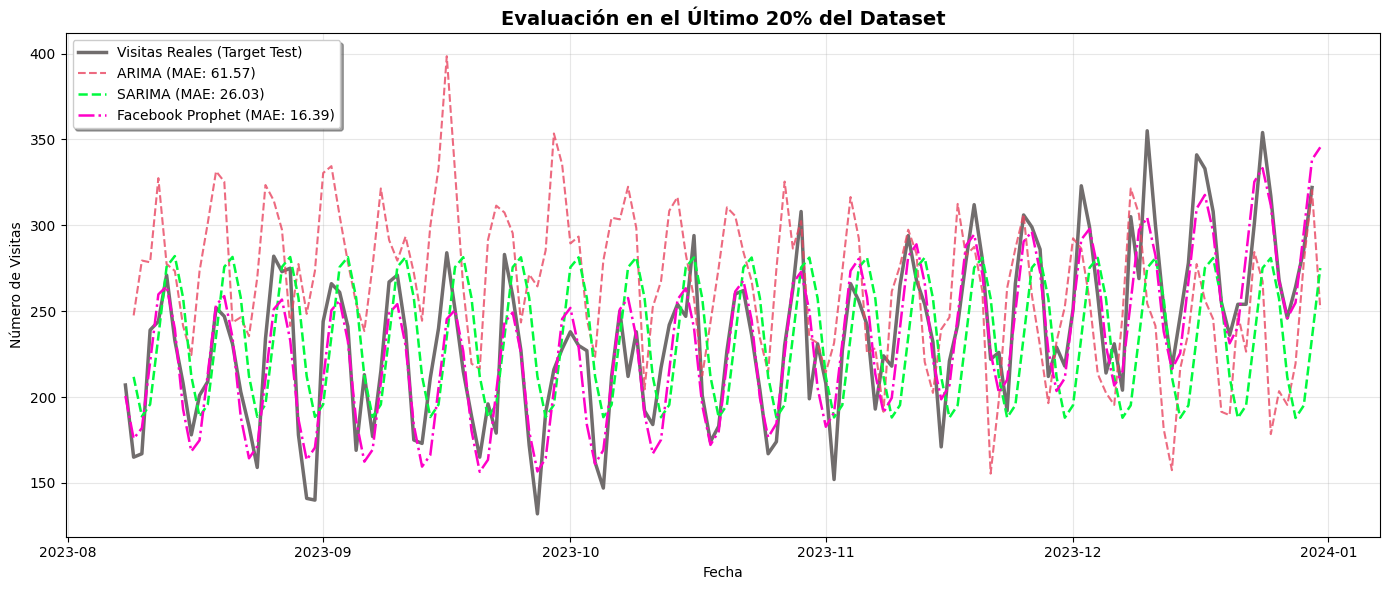

In [52]:
plt.figure(figsize=(14, 6))

# Línea base real de lo que ocurrió en el 20% de test
plt.plot(y_test.index, y_test.values, label='Visitas Reales (Target Test)', color="#716D6D", linewidth=2.5)

# Líneas predictivas de los modelos
plt.plot(y_test.index[-len(pred_arima):], pred_arima, label=f'ARIMA (MAE: {mae_arima:.2f})', linestyle='--', color='#E94560', alpha=0.8)
plt.plot(y_test.index[-len(pred_sarimax):], pred_sarimax, label=f'SARIMA (MAE: {mae_sarimax:.2f})', linestyle='--', color="#00FA3E", linewidth=1.8)
plt.plot(y_test.index[-len(pred_prophet):], pred_prophet, label=f'Facebook Prophet (MAE: {mae_prophet:.2f})', linestyle='-.', color="#FF00C8", linewidth=1.8)

plt.title('Evaluación en el Último 20% del Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Número de Visitas')
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()